In [1]:


import pandas as pd

import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter


In [3]:
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Load and explore dataset

In [4]:
df = pd.read_csv("/content/train (1).csv")
print("Shape of dataset:", df.shape)
print(df.head(3))

Shape of dataset: (5574, 2)
                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1


In [5]:
print("\nClass distribution:")
print(df['label'].value_counts())


Class distribution:
label
0    4827
1     747
Name: count, dtype: int64


Basic cleaning

In [6]:
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # remove urls
    text = re.sub(r"\d+", "", text) # remove digits
    text = re.sub(r"[^\w\s]", "", text) # remove punctuation
    tokens = nltk.word_tokenize(text)
    tokens = [ps.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

In [8]:
nltk.download('punkt_tab')

print(df.columns)


df['clean_text'] = df['sms'].apply(clean_text)
print("\nSample cleaned text:\n", df['clean_text'].head(5))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Index(['sms', 'label'], dtype='object')

Sample cleaned text:
 0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
Name: clean_text, dtype: object


Corpus Analysis

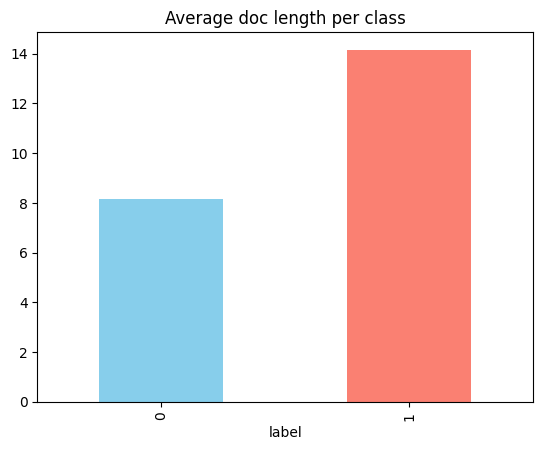

In [9]:
df['length'] = df['clean_text'].apply(lambda x: len(x.split()))
avg_len = df.groupby('label')['length'].mean()
avg_len.plot(kind='bar', color=['skyblue','salmon'], title="Average doc length per class")
plt.show()

Top 10 words for each class

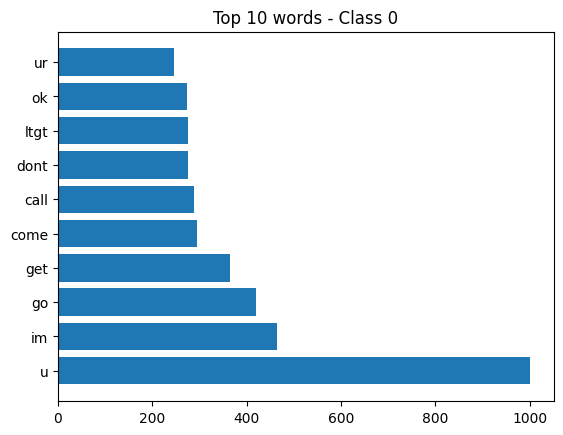

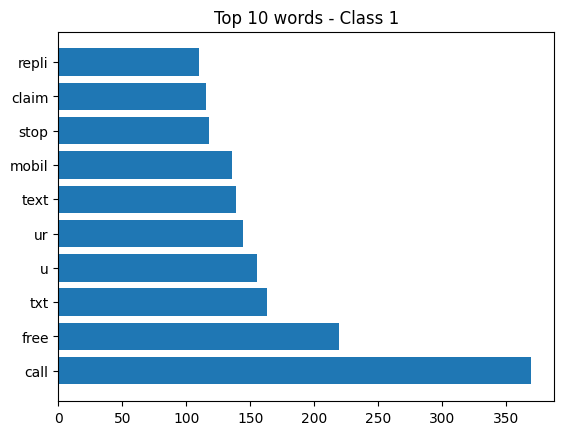

In [10]:

for label in [0,1]:
    words = " ".join(df[df['label']==label]['clean_text']).split()
    counter = Counter(words)
    common = counter.most_common(10)
    words_, freq_ = zip(*common)
    plt.barh(words_, freq_)
    plt.title(f"Top 10 words - Class {label}")
    plt.show()

Bigrams

In [11]:

vectorizer = CountVectorizer(ngram_range=(2,2))
X_bigrams = vectorizer.fit_transform(df['clean_text'])
vocab = vectorizer.get_feature_names_out()
counts = np.array(X_bigrams.sum(axis=0)).flatten()
bigram_freq = Counter(dict(zip(vocab, counts)))
print("\nVocabulary size:", len(vocab))
print("Most common bigrams:", bigram_freq.most_common(10))


Vocabulary size: 29895
Most common bigrams: [('gon na', np.int64(58)), ('pleas call', np.int64(55)), ('call later', np.int64(52)), ('ill call', np.int64(48)), ('let know', np.int64(42)), ('dont know', np.int64(39)), ('sorri ill', np.int64(39)), ('wan na', np.int64(38)), ('new year', np.int64(32)), ('po box', np.int64(32))]


Spacy pipeline

In [12]:
nlp = spacy.load("en_core_web_sm")

In [13]:
def get_lemmas(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc if token.is_alpha]

In [14]:
df['lemmas'] = df['sms'].apply(get_lemmas)

POS tagging + filter verbs and adjectives

In [15]:
verbs = []
adjs = []
for doc in nlp.pipe(df['sms'], batch_size=50):
    for token in doc:
        if token.pos_ == "VERB":
            verbs.append(token.lemma_)
        elif token.pos_ == "ADJ":
            adjs.append(token.lemma_)

In [16]:
verb_freq = Counter(verbs).most_common(10)
adj_freq = Counter(adjs).most_common(10)

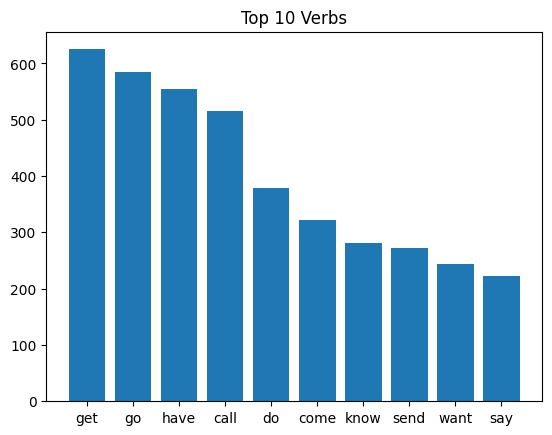

In [17]:
verbs_, vfreq_ = zip(*verb_freq)
plt.bar(verbs_, vfreq_)
plt.title("Top 10 Verbs")
plt.show()

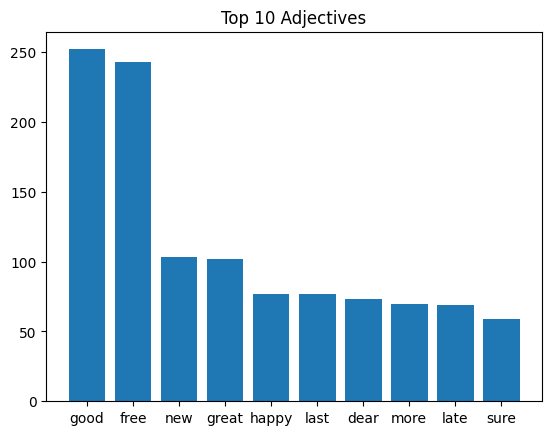

In [18]:
adjs_, afreq_ = zip(*adj_freq)
plt.bar(adjs_, afreq_)
plt.title("Top 10 Adjectives")
plt.show()

Classification

In [19]:
X = df['clean_text']
y = df['label']

In [20]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [22]:
models = {
    "LogReg": LogisticRegression(max_iter=200),
    "SVM": LinearSVC(),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [23]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))


LogReg Results:
Accuracy: 0.9605381165919282
Precision: 0.968
Recall: 0.7515527950310559
F1: 0.8461538461538461

SVM Results:
Accuracy: 0.97847533632287
Precision: 0.959731543624161
Recall: 0.8881987577639752
F1: 0.9225806451612903

RF Results:
Accuracy: 0.9766816143497757
Precision: 1.0
Recall: 0.8385093167701864
F1: 0.9121621621621622


Top features from logistic regression

In [24]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr.coef_[0]
top_pos = np.argsort(coef)[-10:]
top_neg = np.argsort(coef)[:10]

In [25]:
print("\nTop 10 positive (disaster) words:", feature_names[top_pos])
print("Top 10 negative (non-disaster) words:", feature_names[top_neg])


Top 10 positive (disaster) words: ['prize' 'servic' 'repli' 'call' 'text' 'free' 'stop' 'mobil' 'claim'
 'txt']
Top 10 negative (non-disaster) words: ['ltgt' 'im' 'ok' 'ill' 'later' 'come' 'sir' 'home' 'da' 'got']


TF-IDF (Unigram, Bigram, Trigram)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [27]:
X = df['sms']
Y = df['label'] # Corrected from y = df['sms']

In [28]:
tfidf_uni = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
tfidf_bi  = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_tri = TfidfVectorizer(max_features=5000, ngram_range=(1,3))

In [29]:
vectorizers = {'Unigram': tfidf_uni, 'Bigram': tfidf_bi, 'Trigram': tfidf_tri}

Artificial Neural Network (ANN)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [31]:
for name, vec in vectorizers.items():
    print(f"\n--- ANN Model ({name}) ---")
    X_tfidf = vec.fit_transform(X)
    X_train, X_test, Y_train, Y_test = train_test_split(X_tfidf, Y, test_size=0.2, random_state=42)


--- ANN Model (Unigram) ---

--- ANN Model (Bigram) ---

--- ANN Model (Trigram) ---


In [32]:
model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Initialize variables to store final predictions and true labels for ANN (Trigram)
y_pred_ann = None
y_test_ann_final = None

for name, vec in vectorizers.items():
    print(f"\n--- ANN Model ({name}) ---")
    X_tfidf_current = vec.fit_transform(X)
    X_train_current, X_test_current, Y_train_current, Y_test_current = train_test_split(X_tfidf_current, Y, test_size=0.2, random_state=42)

    # Re-define the ANN model for each vectorizer within the loop to ensure correct input_shape
    ann_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_current.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model (set verbose to 0 to minimize output during loop)
    ann_model.fit(X_train_current.toarray(), Y_train_current, epochs=3, batch_size=64, verbose=0)

    # Evaluate the model
    loss, acc = ann_model.evaluate(X_test_current.toarray(), Y_test_current, verbose=0)
    print(f"Accuracy ({name}): {acc:.4f}")

    # Capture predictions and true labels for the last model (Trigram) to be used later
    if name == 'Trigram':
        y_pred_ann = (ann_model.predict(X_test_current.toarray()) > 0.5).astype("int32")
        y_test_ann_final = Y_test_current


--- ANN Model (Unigram) ---
Accuracy (Unigram): 0.9839

--- ANN Model (Bigram) ---
Accuracy (Bigram): 0.9857

--- ANN Model (Trigram) ---
Accuracy (Trigram): 0.9857
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


LSTM Model

In [34]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM

In [35]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)
seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(seq, maxlen=50)

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X_pad, Y, test_size=0.2, random_state=42)

In [37]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=50),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\n--- LSTM Model ---")
model.fit(X_train, Y_train, epochs=3, batch_size=64, verbose=1)
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"LSTM Accuracy: {acc:.4f}")


--- LSTM Model ---
Epoch 1/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9186 - loss: 0.2240
Epoch 2/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9863 - loss: 0.0500
Epoch 3/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9919 - loss: 0.0268
LSTM Accuracy: 0.9865


In [39]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.3 MB/s eta 0:00:00


Word2Vec + LSTM

In [40]:
import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import numpy as np

In [41]:
sentences = [text.split() for text in df['clean_text']]


In [42]:
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)
print("Word2Vec model trained.")


Word2Vec model trained.


Data for LSTM

In [43]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
word_index = tokenizer.word_index
print(f"Total unique words: {len(word_index)}")


Total unique words: 7103


Pad sequence to sam length

In [44]:
max_len = 50
X_pad = pad_sequences(sequences, maxlen=max_len)
y = df['label']

Build embedding matrix using the Word2Vec model

In [45]:
embedding_dim = 100
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

Spilting data

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

Build LSTM model

In [47]:
model = Sequential()
model.add(Embedding(input_dim=len(word_index) + 1,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_len,
                    trainable=False))

In [48]:
model.add(LSTM(128, dropout=0.3, recurrent_dropout=0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [49]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\n--- Training LSTM with Word2Vec embeddings ---")
model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2, verbose=1)


--- Training LSTM with Word2Vec embeddings ---
Epoch 1/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8632 - loss: 0.4056 - val_accuracy: 0.8307 - val_loss: 0.3588
Epoch 2/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.8652 - loss: 0.3115 - val_accuracy: 0.8587 - val_loss: 0.3227
Epoch 3/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - accuracy: 0.8705 - loss: 0.3093 - val_accuracy: 0.8565 - val_loss: 0.3208


Evaluate Model

In [50]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Accuracy (Word2Vec): {acc:.4f}")
y_pred_lstm = (model.predict(X_test) > 0.5).astype("int32")

LSTM Accuracy (Word2Vec): 0.8556
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


BERT Model

In [51]:
!pip install transformers --quiet

In [52]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

Loading BERT tokenizer

In [53]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preparing data

In [54]:
texts = df['clean_text'].tolist()
labels = df['label'].tolist()

Spiliting data

In [55]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
# Tokenize your data after splitting
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=64)

Tokenize text

In [56]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=64)

Create Dataset class

In [57]:
class SpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

Createing Data loaders

In [58]:
train_dataset = SpamDataset(train_encodings, train_labels)
test_dataset = SpamDataset(test_encodings, test_labels)

In [59]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Loading pre-trained BERT model

In [60]:
bert_classification_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Optimizer

In [61]:
from torch.optim import AdamW

optimizer = AdamW(bert_classification_model.parameters(), lr=2e-5)

Use GPU if available

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_classification_model.to(device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Training loop (simple version)

In [63]:
!pip install transformers torch


In [ ]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import torch

Load tokenizer and model

In [64]:
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_classification_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [66]:
texts = df['clean_text'].tolist()
labels = df['label'].tolist()
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Function to tokenize (moved here to resolve NameError)
def tokenize_function(texts, labels, max_length=64):
    inputs = tokenizer(texts, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    # Convert numerical labels to strings for tokenization
    label_strings = [str(label) for label in labels]
    outputs = tokenizer(label_strings, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    inputs["labels"] = outputs["input_ids"]
    return inputs

# Use the tokenize_function to prepare both encoder and decoder inputs
train_encodings = tokenize_function(train_texts, train_labels)
test_encodings = tokenize_function(test_texts, test_labels)

In [67]:
# This line is not needed when using CustomDataset with encode_data for EncoderDecoderModel
# as labels are already part of train_encodings.
# labels = torch.tensor(list(y_train))

In [68]:
# Custom dataset
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

Create DataLoader

In [69]:
train_dataset = TweetDataset(train_encodings, train_labels)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

test_dataset = TweetDataset(test_encodings, test_labels)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


 Move model to GPU if available

In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_classification_model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [71]:
# Optimizer
optimizer = AdamW(bert_classification_model.parameters(), lr=2e-5)

In [72]:
small_dataset = list(train_loader)[:10]
for epoch in range(1):
    print(f"\nEpoch {epoch+1}")
    for batch in small_dataset:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = bert_classification_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Loss: {loss.item():.4f}")


Epoch 1
Loss: 0.3977


Evaluation

In [73]:
bert_classification_model.eval()
bert_classification_preds, bert_classification_true_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = bert_classification_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        bert_classification_preds.extend(predictions)
        bert_classification_true_labels.extend(labels.cpu().numpy())


Results

In [74]:
print("\nClassification Report:")
print(classification_report(bert_classification_true_labels, bert_classification_preds))
print(f"Accuracy: {accuracy_score(bert_classification_true_labels, bert_classification_preds):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       954
           1       0.00      0.00      0.00       161

    accuracy                           0.86      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.73      0.86      0.79      1115

Accuracy: 0.8556


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Bert to Bert

In [75]:
from transformers import BertTokenizer, EncoderDecoderModel, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch

In [76]:
# Load pre-trained tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = EncoderDecoderModel.from_encoder_decoder_pretrained('bert-base-uncased', 'bert-base-uncased')

# Set the decoder_start_token_id
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
cls.seq_relationship.bias                                          | UNEXPECTED | 
bert.pooler.dense.weight                                           | UNEXPECTED | 
cls.seq_relationship.weight                                        | UNEXPECTED | 
bert.pooler.dense.bias                                             | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.self.query.weight       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.key.bias           | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias   | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.key.weight         | MISSING    | 
bert.encoder.layer.{0...11}.crossat

In [77]:
# Use already defined train/test data
train_texts_data = train_texts
train_labels_data = train_labels
test_texts_data = test_texts
test_labels_data = test_labels

In [78]:
# Function to tokenize
def tokenize_function(texts, labels, max_length=64):
    inputs = tokenizer(texts, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    # Convert numerical labels to strings for tokenization
    label_strings = [str(label) for label in labels]
    outputs = tokenizer(label_strings, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    inputs["labels"] = outputs["input_ids"]
    return inputs

In [79]:
# Dataset class
class BertDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings["input_ids"])

train_dataset = BertDataset(train_encodings)
test_dataset = BertDataset(test_encodings)

In [80]:
# Training settings (simple version)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,  # keep small to test
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    logging_steps=10,
    save_strategy="no",
    learning_rate=5e-5,
    report_to="none"
)

In [81]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [82]:

# Train model
print("Training BERT to BERT model...")
trainer.train()

Training BERT to BERT model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Step,Training Loss
10,8.321219
20,2.571535
30,0.924903
40,0.304286
50,0.164924
60,0.128035
70,0.112264
80,0.191119
90,0.104035
100,0.068804


Step,Training Loss
10,8.321219
20,2.571535
30,0.924903
40,0.304286
50,0.164924
60,0.128035
70,0.112264
80,0.191119
90,0.104035
100,0.068804


TrainOutput(global_step=2230, training_loss=0.08487118571462118, metrics={'train_runtime': 6646.1396, 'train_samples_per_second': 0.671, 'train_steps_per_second': 0.336, 'total_flos': 341923979255040.0, 'train_loss': 0.08487118571462118, 'epoch': 1.0})

In [83]:
# This cell attempted to use EncoderDecoderModel.generate() for classification,
# which is not its intended use and was causing issues. The predictions for
# the BertForSequenceClassification model are now explicitly saved.
# print("Evaluating model...")
# model.eval()
# preds = []
# for text in test_texts:
#     input_ids = tokenizer.encode(text, return_tensors='pt', truncation=True, padding=True).to(device)
#     try:
#         output_ids = model.generate(input_ids=input_ids, max_new_tokens=1, num_beams=1, early_stopping=True)
#         pred_label_str = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
#         if pred_label_str in ['0', '1']:
#             preds.append(int(pred_label_str))
#         else:
#             preds.append(0)
#     except Exception as e:
#         print(f"Error generating prediction for text: {text[:50]}... Error: {e}")
#         preds.append(0)
# print("Classification Report:\n", classification_report(test_labels, preds))


# Confusion Matrices for All Models

In [84]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [85]:
all_models = {
    "ANN (Trigram)": y_pred_ann,
    "LSTM": y_pred_lstm, # This y_pred_lstm comes from the Word2Vec + LSTM training
    "BERT to BERT": bert_classification_preds
}

In [86]:
true_values = {
    "ANN (Trigram)": y_test_ann_final,
    "LSTM": y_test,
    "BERT to BERT": bert_classification_true_labels
}

ANN (Trigram): y_true=1115, y_pred=1115


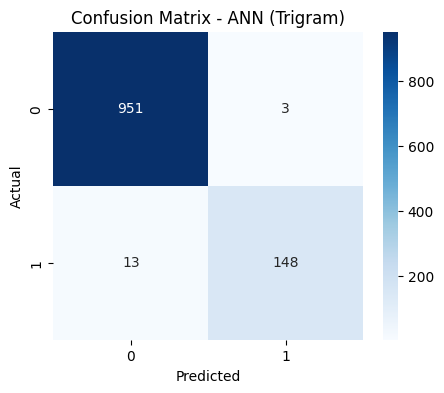

LSTM: y_true=1115, y_pred=1115


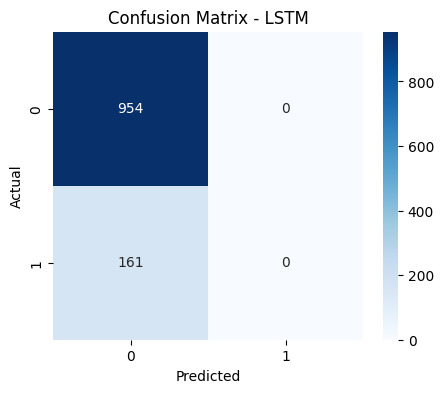

BERT to BERT: y_true=1115, y_pred=1115


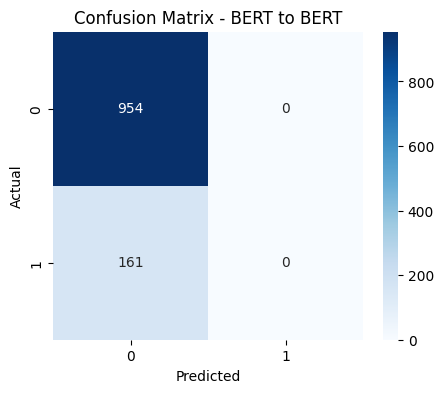

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for name in all_models:
    y_true = true_values[name]
    y_pred = all_models[name]

    # Debug print
    print(f"{name}: y_true={len(y_true)}, y_pred={len(y_pred)}")

    # Ensure same length
    if len(y_true) != len(y_pred):

        continue

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Classification Report for BERT to BERT Model:

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       954
           1       0.00      0.00      0.00       161

    accuracy                           0.86      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.73      0.86      0.79      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


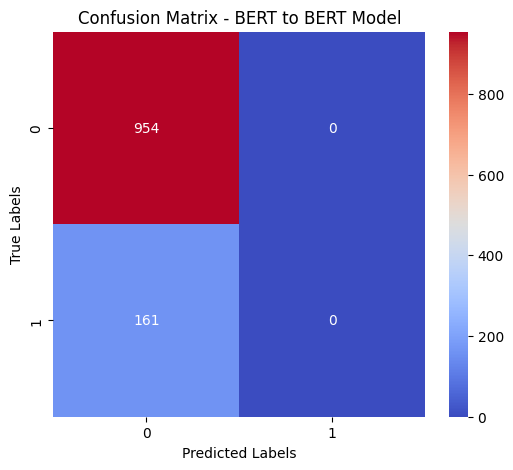

In [88]:
# Confusion Matrix for BERT to BERT Model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# True and predicted labels for BERT to BERT model
y_true = bert_classification_true_labels
y_pred = bert_classification_preds

# Confusion matrix calculation
cm = confusion_matrix(y_true, y_pred)

print("Classification Report for BERT to BERT Model:\n")
print(classification_report(y_true, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - BERT to BERT Model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
